# Cluster Analysis
# Import the relevant libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans

# Load the data

In [12]:
data = pd.read_csv("C:/Users/prince/Desktop/3.01.+Country+clusters.csv")

In [13]:
data

,Country,Latitude,Longitude,Language
0,USA,44.97,-103.77,English
1,Canada,62.40,-96.80,English
2,France,46.75,2.40,French
3,UK,54.01,-2.53,English
4,Germany,51.15,10.40,German
5,Australia,-25.45,133.11,English


# Map the data

In [14]:
data_mapped = data.copy()
data_mapped['Language']=data_mapped['Language'].map({'English':0,'French':1,'German':2})
data_mapped

,Country,Latitude,Longitude,Language
0,USA,44.97,-103.77,0
1,Canada,62.40,-96.80,0
2,France,46.75,2.40,1
3,UK,54.01,-2.53,0
4,Germany,51.15,10.40,2
5,Australia,-25.45,133.11,0


# Plot the data

<function matplotlib.pyplot.show(close=None, block=None)>

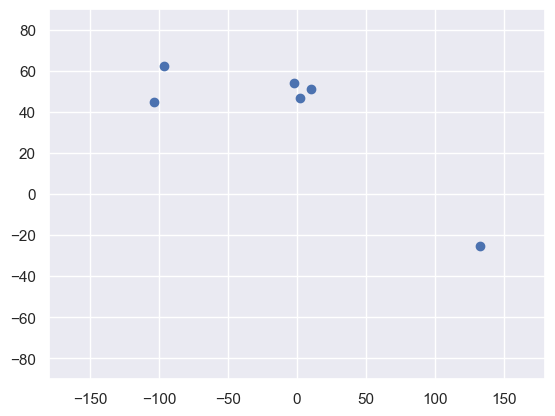

In [15]:
plt.scatter(data['Longitude'],data['Latitude'])
plt.xlim(-180,180)
plt.ylim(-90,90)
plt.show

# Select the features 

In [16]:
x = data_mapped.iloc[:,1:3]

 DataFrame.iloc(row indices,column indices) slices the data frame , given rows and columns to be kept 

In [17]:
x

,Latitude,Longitude
0,44.97,-103.77
1,62.40,-96.80
2,46.75,2.40
3,54.01,-2.53
4,51.15,10.40
5,-25.45,133.11


# Clustering 

In [27]:
Kmeans = KMeans(2)

The value in the bracket is k (the numbers of clusters)

In [28]:
Kmeans.fit(x)

C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


The kmeans will fit 3 clusters to x

# Clustering results

In [29]:
identified_clusters = Kmeans.fit_predict(x)
identified_clusters

C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 0, 0, 0, 1], dtype=int32)

sklearn.cluster.KMeans.fit_predict(x) returns the cluster predictions in an array

In [30]:
data_with_clusters = data.copy()
data_with_clusters['cluster'] = identified_clusters
data_with_clusters

,Country,Latitude,Longitude,Language,cluster
0,USA,44.97,-103.77,English,0
1,Canada,62.40,-96.80,English,0
2,France,46.75,2.40,French,0
3,UK,54.01,-2.53,English,0
4,Germany,51.15,10.40,German,0
5,Australia,-25.45,133.11,English,1


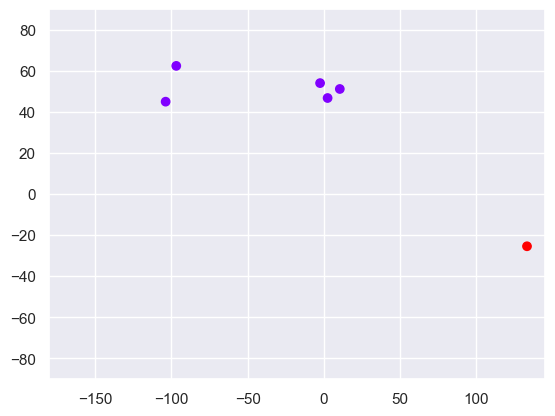

In [31]:
plt.scatter(data_with_clusters['Longitude'],data_with_clusters['Latitude'],c=data_with_clusters['cluster'],cmap='rainbow')
plt.xlim(-180.180)
plt.ylim(-90,90)
plt.show()

# Selecting the number of clusters
# WCSS

In [32]:
Kmeans.inertia_

13205.758119999999

In [35]:
WCSS = []
for i in range(1,7):
    Kmeans = KMeans(i)
    Kmeans.fit(x)
    WCSS_iter = Kmeans.inertia_
    WCSS.append(WCSS_iter)

C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

In [36]:
WCSS

[42601.91356666667,
 17243.964500000002,
 288.10523333333333,
 111.91233333333332,
 38.50624999999998,
 0.0]

# The Elbow method

<function matplotlib.pyplot.show(close=None, block=None)>

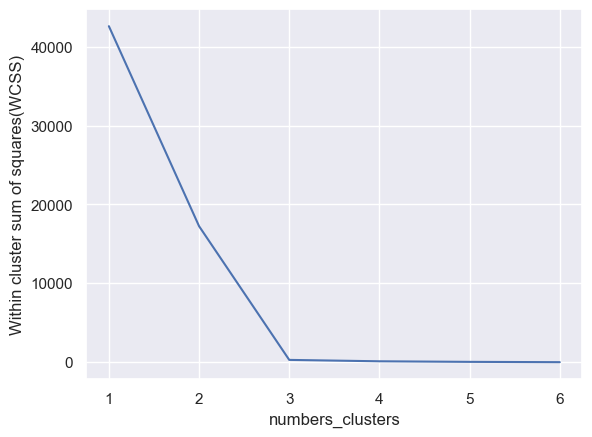

In [48]:
numbers_clusters = range(1,7)
plt.plot(numbers_clusters,WCSS)
plt.xlabel('numbers_clusters')
plt.ylabel('Within cluster sum of squares(WCSS)')
plt.show

# Another example on cluster analysis

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans

In [53]:
dataa = pd.read_csv("C:/Users/prince/Desktop/Categorical.csv")

In [54]:
dataa

,name,Longitude,Latitude,continent
0,Aruba,-69.982677,12.520880,North America
1,Afghanistan,66.004734,33.835231,Asia
2,Angola,17.537368,-12.293361,Africa
3,Anguilla,-63.064989,18.223959,North America
4,Albania,20.049834,41.142450,Europe
...,...,...,...,...
236,Samoa,-172.164851,-13.753243,Oceania
237,Yemen,47.586762,15.909280,Asia
238,South Africa,25.083901,-29.000341,Africa
239,Zambia,27.774759,-13.458242,Africa


In [56]:
dataa_mapped = dataa.copy()
dataa_mapped['continent'] = dataa_mapped['continent'].map({'North America':0,'Asia':1,'Africa':2,'Europe':3,'South America':4,'Oceania':5,'Antartica':6,'Seven Seas':7})
dataa_mapped

,name,Longitude,Latitude,continent
0,Aruba,-69.982677,12.520880,0.0
1,Afghanistan,66.004734,33.835231,1.0
2,Angola,17.537368,-12.293361,2.0
3,Anguilla,-63.064989,18.223959,0.0
4,Albania,20.049834,41.142450,3.0
...,...,...,...,...
236,Samoa,-172.164851,-13.753243,5.0
237,Yemen,47.586762,15.909280,1.0
238,South Africa,25.083901,-29.000341,2.0
239,Zambia,27.774759,-13.458242,2.0


<function matplotlib.pyplot.show(close=None, block=None)>

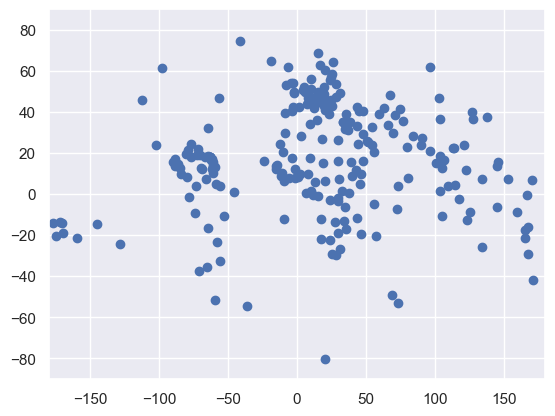

In [57]:
plt.scatter(data['Longitude'],data['Latitude'])
plt.xlim(-180,180)
plt.ylim(-90,90)
plt.show

In [59]:
p = dataa_mapped.iloc[:,1:3]

In [60]:
p

,Longitude,Latitude
0,-69.982677,12.520880
1,66.004734,33.835231
2,17.537368,-12.293361
3,-63.064989,18.223959
4,20.049834,41.142450
...,...,...
236,-172.164851,-13.753243
237,47.586762,15.909280
238,25.083901,-29.000341
239,27.774759,-13.458242


In [81]:
Kmeans = KMeans(3)

In [82]:
Kmeans.fit(p)

C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [83]:
p_clusters = Kmeans.fit_predict(p)
p_clusters

C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 2, 2, 1, 2, 0, 0, 0, 0, 0, 0,
       2, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 1, 2, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 2, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       2, 1, 2, 2, 1, 0, 1, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       2, 2, 0, 0, 0, 2, 1, 1, 2, 0, 0, 2, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0,
       2, 1, 0, 0, 0, 0, 2, 1, 2, 0, 0, 0, 2, 0, 2, 2, 0, 0, 1, 0, 0, 2,
       0, 2, 0, 2, 0, 1, 1, 0, 0, 2, 2, 2, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1,
       2, 0, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 2, 0, 0, 2, 1, 1, 0,
       0, 2, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 1, 0, 0, 0, 0],
      dtype=int32)

In [84]:
pp_clusters = dataa.copy()
pp_clusters['clusters'] = p_clusters
pp_clusters

,name,Longitude,Latitude,continent,clusters
0,Aruba,-69.982677,12.520880,North America,1
1,Afghanistan,66.004734,33.835231,Asia,0
2,Angola,17.537368,-12.293361,Africa,0
3,Anguilla,-63.064989,18.223959,North America,1
4,Albania,20.049834,41.142450,Europe,0
...,...,...,...,...,...
236,Samoa,-172.164851,-13.753243,Oceania,1
237,Yemen,47.586762,15.909280,Asia,0
238,South Africa,25.083901,-29.000341,Africa,0
239,Zambia,27.774759,-13.458242,Africa,0


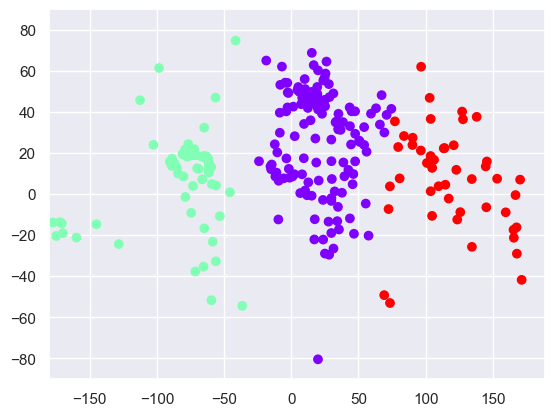

In [85]:
plt.scatter(pp_clusters['Longitude'],pp_clusters['Latitude'],c=pp_clusters['clusters'],cmap='rainbow')
plt.xlim(-180.180)
plt.ylim(-90,90)
plt.show()

In [86]:
Kmeans.inertia_

325235.52237055905

In [87]:
WCSS = []
for i in range(1,15):
    Kmeans = KMeans(i)
    Kmeans.fit(x)
    WCSS_iter = Kmeans.inertia_
    WCSS.append(WCSS_iter)

C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\prince\Downloads\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

In [88]:
WCSS

[1413859.6798344275,
 657012.0797586325,
 325255.1539807804,
 256734.58387798432,
 195165.31430609082,
 155370.25526155208,
 127508.56714440485,
 103719.81382400187,
 84967.41720068287,
 79265.68942543787,
 71261.13812019618,
 65299.90775334237,
 59080.56900747344,
 56581.24590192925]

For 241 rows we used i from 1 to 242

<function matplotlib.pyplot.show(close=None, block=None)>

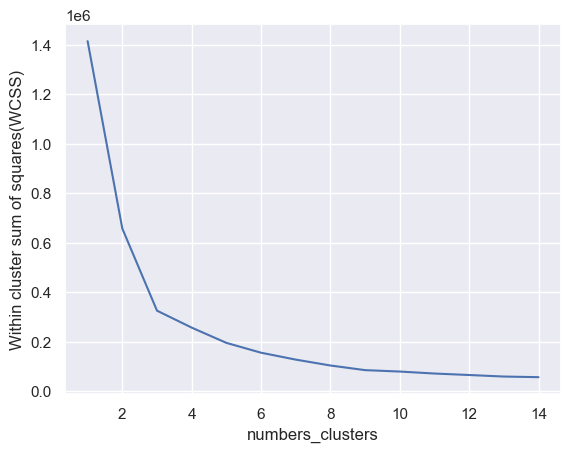

In [89]:
numbers_clusters = range(1,15)
plt.plot(numbers_clusters,WCSS)
plt.xlabel('numbers_clusters')
plt.ylabel('Within cluster sum of squares(WCSS)')
plt.show